## 100 Neuron challenge

Training a model with less than 100 neurons to 99.5% accuracy

### 4.1 Imports

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import cv2
from torch.utils.data import DataLoader, TensorDataset

# Check for GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


### 4.2 Load up Baarle Hertog data

In [18]:
m = cv2.imread('data/Baarle-Nassau_-_Baarle-Hertog-en no legend.png')[:, :, (2, 1, 0)]

belgium_color = np.array([251, 234, 81])
netherlands_color = np.array([255, 255, 228])

netherlands_region = ((m - netherlands_color)**2).sum(-1) < 50
belgium_region = ((m - belgium_color)**2).sum(-1) < 10000

b_coords = np.array(np.where(belgium_region)).T.astype('float')
n_coords = np.array(np.where(netherlands_region)).T.astype('float')

# Flip and normalize coordinates to [-1, 1]
belgium_coords_all = np.zeros_like(b_coords)
netherlands_coords_all = np.zeros_like(n_coords)

belgium_coords_all[:, 0] = b_coords[:, 1] / (960 / 2) - 1
belgium_coords_all[:, 1] = (960 - b_coords[:, 0]) / (960 / 2) - 1
netherlands_coords_all[:, 0] = n_coords[:, 1] / (960 / 2) - 1
netherlands_coords_all[:, 1] = (960 - n_coords[:, 0]) / (960 / 2) - 1

In [19]:
np.random.seed(55)
num_points_to_sample = 10000
belgium_coords_sample = belgium_coords_all[np.random.choice(len(belgium_coords_all), 
                                                            num_points_to_sample), :]
netherlands_coords_sample=netherlands_coords_all[np.random.choice(len(netherlands_coords_all), 
                                                                    num_points_to_sample), :]
X_sample = np.vstack((netherlands_coords_sample, belgium_coords_sample))
y_sample = np.concatenate((np.zeros(len(belgium_coords_sample)), 
                           np.ones(len(netherlands_coords_sample)))).astype('int')

rI=np.arange(len(y_sample))
np.random.shuffle(rI)
X_sample=X_sample[rI,:]
y_sample=y_sample[rI]

X_sample = torch.FloatTensor(X_sample)
y_sample = torch.tensor(y_sample)

In [20]:
# Full dataset (no sampling)
belgium_coords = belgium_coords_all
netherlands_coords = netherlands_coords_all

X = np.vstack((netherlands_coords, belgium_coords))
y = np.concatenate((np.zeros(len(netherlands_coords)), 
                    np.ones(len(belgium_coords)))).astype('int')

rI=np.arange(len(y))
np.random.shuffle(rI)
X=X[rI,:]
y=y[rI]

X_tensor = torch.FloatTensor(X)
y_tensor = torch.tensor(y)

In [21]:
X_tensor.shape, y_tensor.shape, X_sample.shape, y_sample.shape

(torch.Size([855665, 2]),
 torch.Size([855665]),
 torch.Size([20000, 2]),
 torch.Size([20000]))

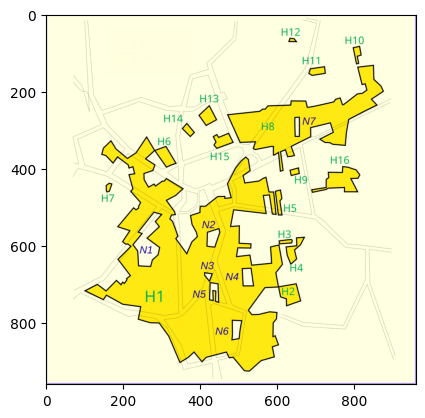

In [22]:
plt.imshow(m)

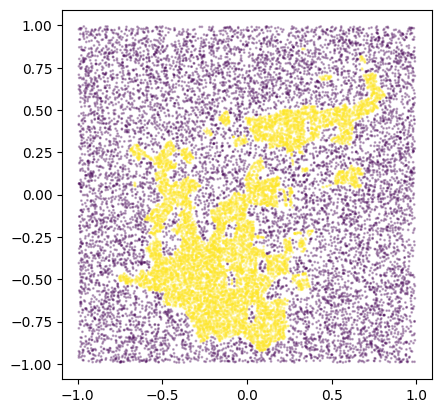

In [23]:
plt.scatter(X_sample[:,0], X_sample[:,1], c=y_sample, s=1, alpha=0.3); 
plt.axis('square');

### 4.3 Theoretical Optimum

In this section we calculate the theoretical optimal structure of the model to be able to model the highest complexity.

In [24]:
def calculate_complexity(layer_amount: int, neuron_per_layer_amount: int) -> int:
    return int(np.floor((neuron_per_layer_amount / 2 + 1)**(2 * (layer_amount - 1)) * ((neuron_per_layer_amount**2 + neuron_per_layer_amount + 2) / 2)))

Peaks found (layer_amount, neuron_per_layer, complexity):
Layers 13, Neurons per layer  7, Complexity 137879064633208688
Layers 16, Neurons per layer  6, Complexity 25364273101350633472
Layers 19, Neurons per layer  5, Complexity 617404199638323298304
Layers 24, Neurons per layer  4, Complexity 97492319316177521213440
Layers 32, Neurons per layer  3, Complexity 32913841823024052986445824
Layers 48, Neurons per layer  2, Complexity 79228162514264337593543950336
Layers 97, Neurons per layer  1, Complexity 12898872036634089064082235207974912


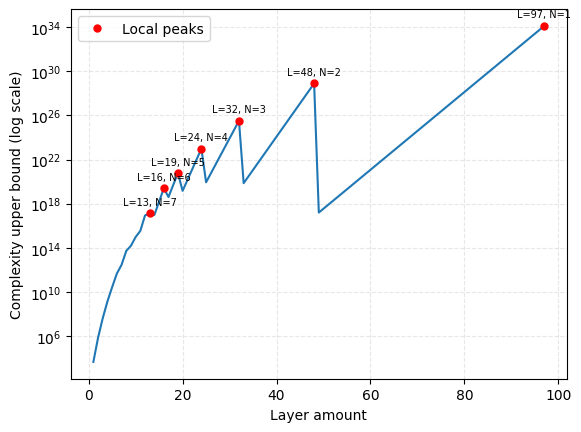

In [25]:
max_amount_of_hidden_neurons = 99 - 2

complexity = []
for layer_amount in range(1, 98):
    complexity.append(calculate_complexity(layer_amount, np.floor(max_amount_of_hidden_neurons / layer_amount)))

plt.semilogy(range(1, 98), complexity)
plt.xlabel("Layer amount")
plt.ylabel("Complexity upper bound (log scale)")
plt.grid(True, which="both", ls="--", alpha=0.3)

layers = np.arange(1, len(complexity) + 1)
complexity_arr = np.array(complexity, dtype=float)

# Local maxima (including boundaries)
peak_mask = np.zeros_like(complexity_arr, dtype=bool)
peak_mask[1:-1] = (complexity_arr[1:-1] > complexity_arr[:-2]) & (complexity_arr[1:-1] > complexity_arr[2:])
peak_mask[0] = complexity_arr[0] > complexity_arr[1]
peak_mask[-1] = complexity_arr[-1] > complexity_arr[-2]

peak_layers = layers[peak_mask]
peak_values = complexity_arr[peak_mask]
peak_neurons = np.floor(max_amount_of_hidden_neurons / peak_layers).astype(int)

plt.semilogy(peak_layers, peak_values, "ro", ms=5, label="Local peaks")
for l, v, n in zip(peak_layers, peak_values, peak_neurons):
    plt.annotate(f"L={l}, N={n}", (l, v), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=7)

plt.legend()

print("Peaks found (layer_amount, neuron_per_layer, complexity):")
for l, n, v in zip(peak_layers, peak_neurons, peak_values):
    print(f"Layers {l:2d}, Neurons per layer {n:2d}, Complexity {int(v)}")

The plot indicates that the complexity of a model with 97 layers and 1 neuron per layer is likely the best option. However this is only an upper bound that is why we will test the performance for all the model represented by a peak. i.e. <br>

Layers 13, Neurons per layer  7 <br>
Layers 16, Neurons per layer  6 <br>
Layers 19, Neurons per layer  5 <br>
Layers 24, Neurons per layer  4 <br>
Layers 32, Neurons per layer  3 <br>
Layers 48, Neurons per layer  2 <br>
Layers 97, Neurons per layer  1 <br>

### 4.4 Networks

In [50]:
model_configurations = [
    {"layer_amount": 1, "neuron_per_layer_amount": 97},
    {"layer_amount": 2, "neuron_per_layer_amount": 48},
    {"layer_amount": 3, "neuron_per_layer_amount": 32},
    {"layer_amount": 4, "neuron_per_layer_amount": 24},
    {"layer_amount": 5, "neuron_per_layer_amount": 19},
    {"layer_amount": 6, "neuron_per_layer_amount": 16},
    {"layer_amount": 7, "neuron_per_layer_amount": 13},
    {"layer_amount": 13, "neuron_per_layer_amount": 7},
    {"layer_amount": 16, "neuron_per_layer_amount": 6},
    {"layer_amount": 19, "neuron_per_layer_amount": 5},
    {"layer_amount": 24, "neuron_per_layer_amount": 4},
    {"layer_amount": 32, "neuron_per_layer_amount": 3},
    {"layer_amount": 48, "neuron_per_layer_amount": 2},
    {"layer_amount": 97, "neuron_per_layer_amount": 1},
]


class NeuralNetwork(nn.Module):
    def __init__(self, hidden_layers: int, neurons_per_layer: int):
        super().__init__()

        if hidden_layers < 1:
            raise ValueError("hidden_layers must be at least 1")

        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(2, neurons_per_layer))
        for _ in range(hidden_layers - 1):
            self.layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
        self.layers.append(nn.Linear(neurons_per_layer, 2))

        self.norms = nn.ModuleList([nn.LayerNorm(neurons_per_layer) for _ in range(hidden_layers)])
        self.activation = nn.LeakyReLU(negative_slope=0.1)
        self.average_gradients = []

        self.normalize_parameters()

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            # Handle first and last layer separately to avoid skip connections on the output layer
            if i == 0:
                x = self.activation(self.norms[i](layer(x)))
            elif i == len(self.layers) - 1:
                x = layer(x)
            
            # Add skip connection for hidden layers
            else:
                x = self.activation(x + self.norms[i](layer(x)))

        return x

    def normalize_parameters(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(
                    layer.weight,
                    a=0.1,
                    mode='fan_in',
                    nonlinearity='leaky_relu'
                )
                nn.init.zeros_(layer.bias)

    def measure_average_gradient(self):
        """Measure the average gradient-to-weight ratio for each linear layer."""
        average_gradients = []

        for layer in self.layers:
            layer_ratios = []

            for param in layer.parameters():
                if param.grad is not None:
                    ratio = param.grad.norm().item() / (param.norm().item() + 1e-12)
                    layer_ratios.append(ratio)

            if layer_ratios:
                average_gradients.append(float(np.mean(layer_ratios)))
            else:
                average_gradients.append(0.0)

        self.average_gradients = average_gradients
        return average_gradients


In [75]:
def viz_decision_boundary(model, res=256):
    plt.clf()
    fig = plt.figure(0, (6, 6))
    ax = fig.add_subplot(111)

    probe = np.zeros((res, res, 2))
    for j, xx in enumerate(np.linspace(-1, 1, res)):
        for k, yy in enumerate(np.linspace(-1, 1, res)):
            probe[j, k] = [yy, xx]
    probe = probe.reshape(res**2, -1)
    probe_logits = model(torch.tensor(probe).float().to(device))
    probe_logits = probe_logits.detach().cpu().numpy().reshape(res, res, 2)

    ax.imshow(m.mean(2), cmap='gray')
    ax.imshow(np.flipud(np.argmax(probe_logits, 2)),
               extent=[0, 960, 960, 0],
               alpha=0.7,
               cmap='viridis')

### 4.5 Training the model

Before training, I had to decide on the network architecture.

1. I started with a simple neural network without skip connections or layer norm. I then realized that the models with more than 4 layers performed terribly. That is why I investigated and found that the gradients in the early layers were almost zero and therefore were not training.
2. I then implemented skip connections. This improved the gradient flow, but models with more than 6 layers still had layers with almost no gradient.
3. I then added layer norm to improve the gradient flow again, which did not help much. So I decided to run a model with 5 layers and 19 neurons each, for a total of 95 hidden neurons and 2 output neurons.

In [52]:
batch_size = 10000
random_seed = 26

torch.manual_seed(random_seed)
X_tensor = torch.FloatTensor(X)
y_tensor = torch.tensor(y)

# Create dataset and dataloader for minibatching
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Training L5-N19
  Epoch 01/10 | Loss: 0.4264 | Acc: 0.7463
  Epoch 02/10 | Loss: 0.2171 | Acc: 0.8814
  Epoch 03/10 | Loss: 0.1580 | Acc: 0.8823
  Epoch 04/10 | Loss: 0.1404 | Acc: 0.8968
  Epoch 05/10 | Loss: 0.1334 | Acc: 0.8900
  Epoch 06/10 | Loss: 0.1232 | Acc: 0.9433
  Epoch 07/10 | Loss: 0.1182 | Acc: 0.9172
  Epoch 08/10 | Loss: 0.1097 | Acc: 0.9128
  Epoch 09/10 | Loss: 0.1102 | Acc: 0.8891
  Epoch 10/10 | Loss: 0.1034 | Acc: 0.9004
Training L6-N16
  Epoch 01/10 | Loss: 0.3873 | Acc: 0.7461
  Epoch 02/10 | Loss: 0.2010 | Acc: 0.8886
  Epoch 03/10 | Loss: 0.1492 | Acc: 0.9071
  Epoch 04/10 | Loss: 0.1349 | Acc: 0.8829
  Epoch 05/10 | Loss: 0.1267 | Acc: 0.8879
  Epoch 06/10 | Loss: 0.1205 | Acc: 0.9300
  Epoch 07/10 | Loss: 0.1100 | Acc: 0.9175
  Epoch 08/10 | Loss: 0.1099 | Acc: 0.9244
  Epoch 09/10 | Loss: 0.0983 | Acc: 0.8586
  Epoch 10/10 | Loss: 0.0964 | Acc: 0.9520
Training L7-N13
  Epoch 01/10 | Loss: 0.3088 | Acc: 0.8410
  Epoch 02/10 | Loss: 0.1821 | Acc: 0.8701
  Epoc

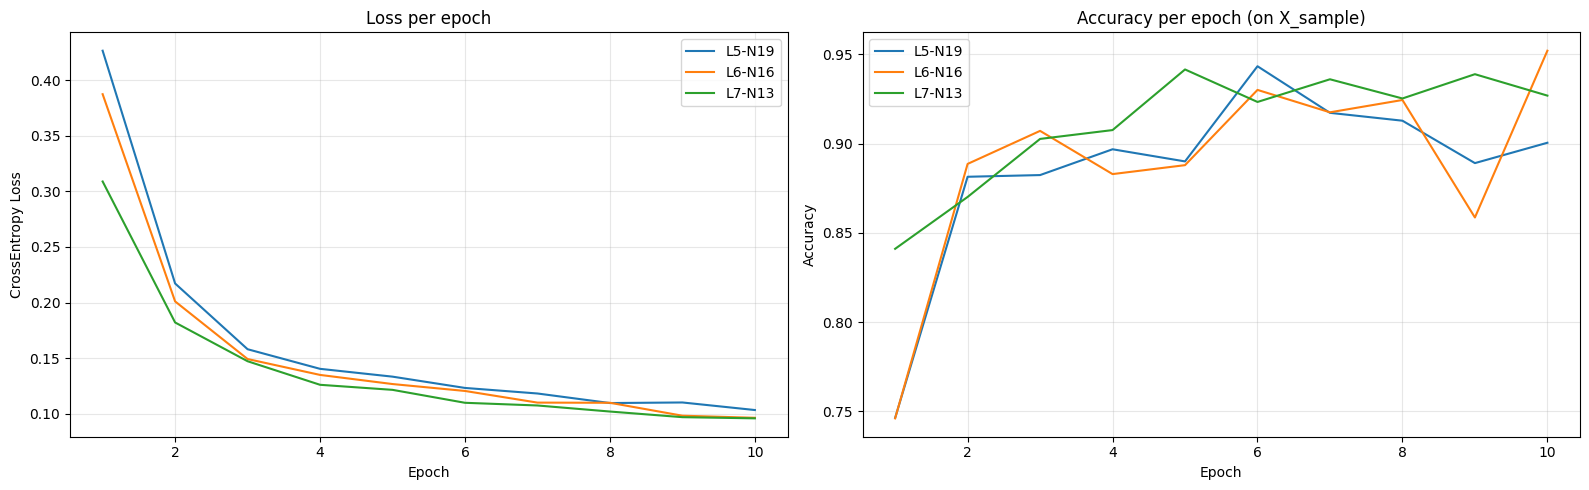

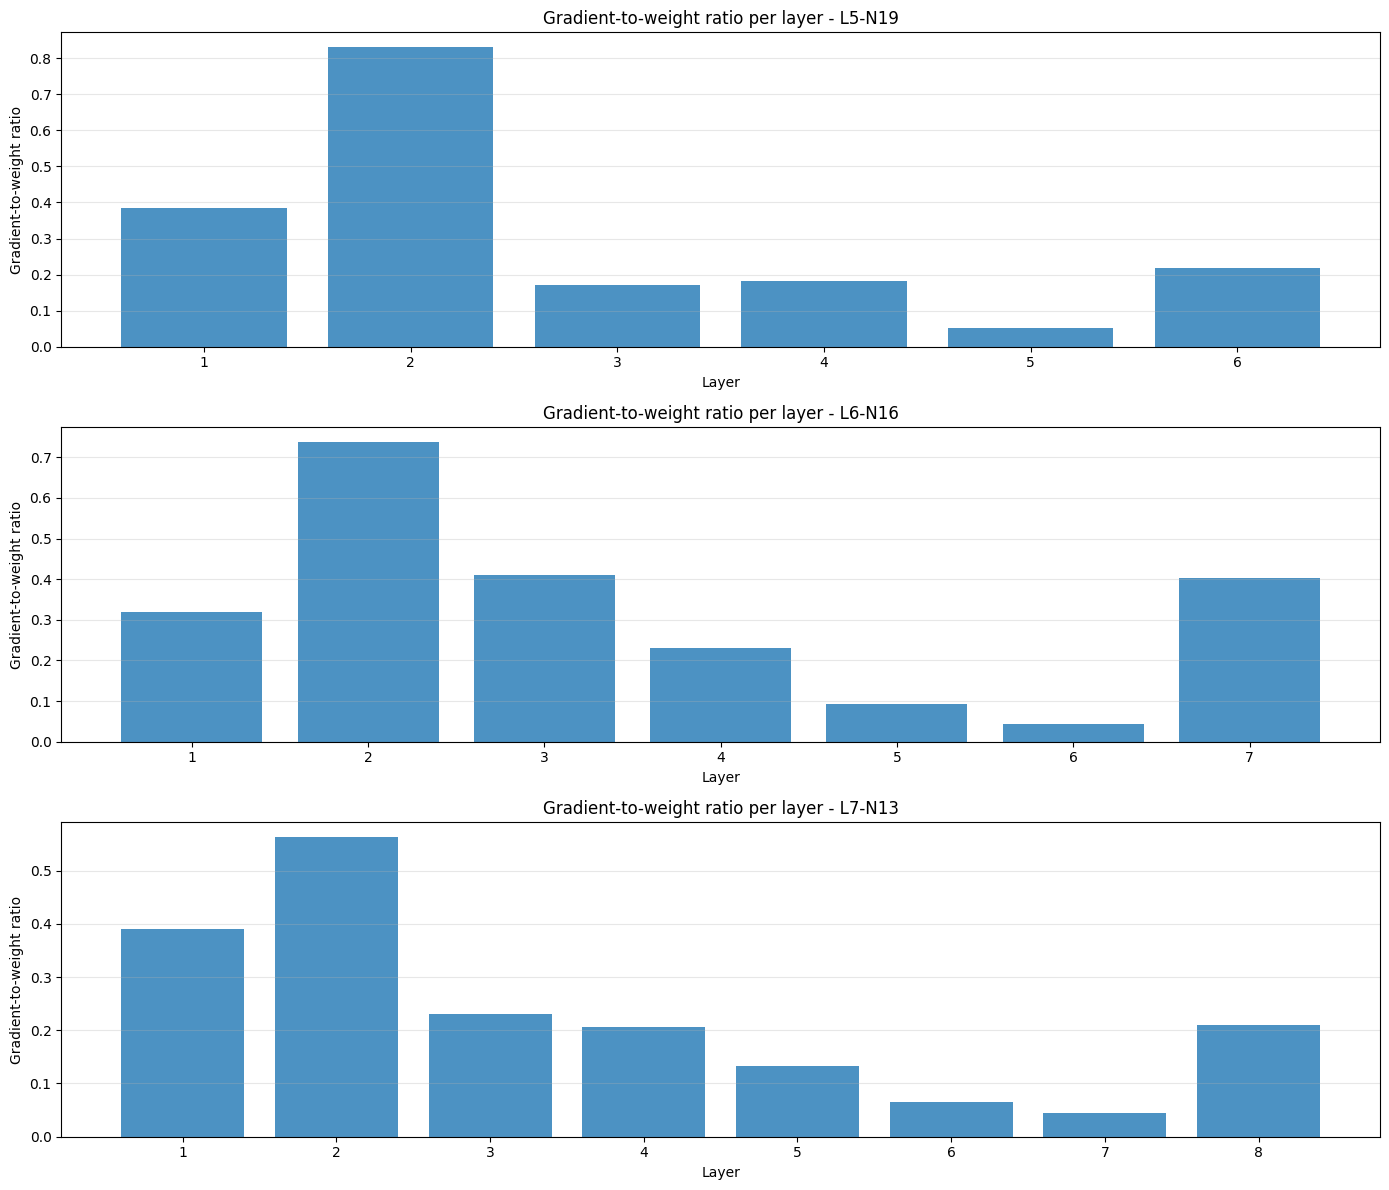

In [73]:
# Train all model configurations for 10 epochs and compare loss/accuracy
epochs = 10
lr = 0.01
results = {}

for cfg in model_configurations[4:7]:
    label = f"L{cfg['layer_amount']}-N{cfg['neuron_per_layer_amount']}"
    print(f"Training {label}")

    model = NeuralNetwork(cfg["layer_amount"], cfg["neuron_per_layer_amount"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    average_gradients = None
    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0

        for batch_X, batch_y in dataloader:
            outputs = model(batch_X.to(device))
            loss = criterion(outputs, batch_y.to(device))

            optimizer.zero_grad()
            loss.backward()

            gradients = model.measure_average_gradient()
            if average_gradients is None:
                average_gradients = gradients
            else:
                average_gradients = [0.8 * avg + 0.2 * new for avg, new in zip(average_gradients, gradients)]

            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches

        model.eval()
        with torch.no_grad():
            outputs_sample = model(X_sample.to(device))
            accuracy = (outputs_sample.argmax(dim=1) == y_sample.to(device)).float().mean().item()

        loss_history.append(avg_loss)
        acc_history.append(accuracy)

        print(f"  Epoch {epoch + 1:02d}/{epochs} | Loss: {avg_loss:.4f} | Acc: {accuracy:.4f}")

    results[label] = {"loss": loss_history, "accuracy": acc_history, "gradients": average_gradients or []}

# Plot loss and accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label, history in results.items():
    axes[0].plot(range(1, epochs + 1), history["loss"], label=label)
    axes[1].plot(range(1, epochs + 1), history["accuracy"], label=label)

axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Accuracy per epoch (on X_sample)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot gradient-to-weight ratio separately for each model
num_models = len(results)
fig, grad_axes = plt.subplots(num_models, 1, figsize=(14, 4 * num_models), squeeze=False)
grad_axes = grad_axes.flatten()

for idx, (label, history) in enumerate(results.items()):
    gradient_values = history["gradients"]
    layer_indices = np.arange(1, len(gradient_values) + 1)
    grad_axes[idx].bar(layer_indices, gradient_values, alpha=0.8)
    grad_axes[idx].set_title(f"Gradient-to-weight ratio per layer - {label}")
    grad_axes[idx].set_xlabel("Layer")
    grad_axes[idx].set_ylabel("Gradient-to-weight ratio")
    grad_axes[idx].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
epochs = 50
lr = 0.1

model = NeuralNetwork(model_configurations[4]["layer_amount"], model_configurations[4]["neuron_per_layer_amount"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

print(f"Training model with {model_configurations[4]['layer_amount']} layers and {model_configurations[4]['neuron_per_layer_amount']} neurons per layer with learning rate {lr}")

Training model with 5 layers and 19 neurons per layer with learning rate 0.1


Training with learning rate:0.0005000000000000001
Epoch [1/50], Loss: 0.0110, Accuracy: 0.9944
Checkpoint saved to checkpoint.pt
Epoch [2/50], Loss: 0.0115, Accuracy: 0.9952
Epoch [3/50], Loss: 0.0112, Accuracy: 0.9935
Checkpoint saved to checkpoint.pt
Epoch [4/50], Loss: 0.0114, Accuracy: 0.9956
Checkpoint saved to checkpoint.pt
Epoch [5/50], Loss: 0.0115, Accuracy: 0.9955
Epoch [6/50], Loss: 0.0114, Accuracy: 0.9933
Epoch [7/50], Loss: 0.0111, Accuracy: 0.9939
Epoch [8/50], Loss: 0.0111, Accuracy: 0.9947
Epoch [9/50], Loss: 0.0111, Accuracy: 0.9946
Epoch [10/50], Loss: 0.0114, Accuracy: 0.9930
Checkpoint saved to checkpoint.pt
Epoch [11/50], Loss: 0.0112, Accuracy: 0.9952
Epoch [12/50], Loss: 0.0111, Accuracy: 0.9932
Checkpoint saved to checkpoint.pt
Epoch [13/50], Loss: 0.0117, Accuracy: 0.9952
Epoch [14/50], Loss: 0.0110, Accuracy: 0.9932
Epoch [15/50], Loss: 0.0116, Accuracy: 0.9933
Epoch [16/50], Loss: 0.0112, Accuracy: 0.9948
Epoch [17/50], Loss: 0.0111, Accuracy: 0.9931
Checkpo

<Figure size 640x480 with 0 Axes>

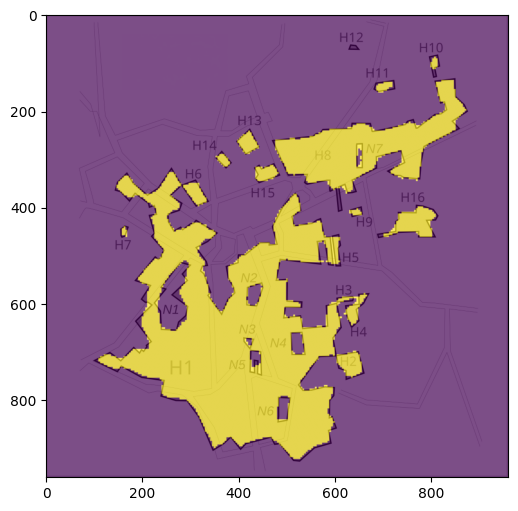

In [67]:
# simulate learning rate decay after 50 epochs
for param_group in optimizer.param_groups:
    param_group['lr'] = param_group['lr'] * 0.1

print(f"Training with learning rate: {optimizer.param_groups[0]['lr']}")

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in dataloader:
        # Forward pass
        outputs = model(batch_X.to(device))
        loss = criterion(outputs, batch_y.to(device))

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    # Calculate average loss for the epoch
    avg_loss = epoch_loss / num_batches

    # Calculate accuracy on the sample dataset
    with torch.no_grad():
        outputs_batch = model(X_sample.to(device))
        accuracy = (torch.argmax(outputs_batch, dim=1) == y_sample.to(device)).sum().item() / len(y_sample)

    if accuracy > 0.995:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'accuracy': accuracy,
        }, 'checkpoint.pt')
        print("Checkpoint saved to checkpoint.pt")

    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

viz_decision_boundary(model)

I trained the model for roughly 300 epochs with

| Epoch range | Learning rate |
| --- | --- |
| 0 to 50 | 0.01 |
| 50 to 100 | 0.001 |
| 100 to 150 | 0.0001 |
| 150 to 300 | 0.0005 |

This yielded a model that reached an accuracy of more than 0.995 after multiple epochs.

### Visualising the model decision boundary that scores accuracy of more than 0.995

<Figure size 640x480 with 0 Axes>

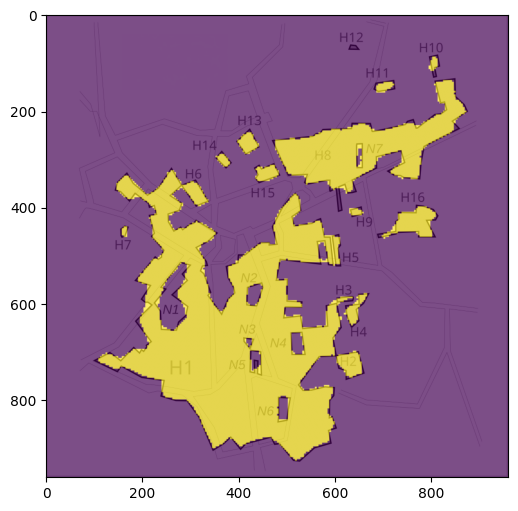

In [76]:
model = NeuralNetwork(model_configurations[4]["layer_amount"], model_configurations[4]["neuron_per_layer_amount"]).to(device)
model.load_state_dict(torch.load('checkpoint.pt')['model_state_dict'])

viz_decision_boundary(model)